In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Number of patients without both surgery_age and preop_age: 139


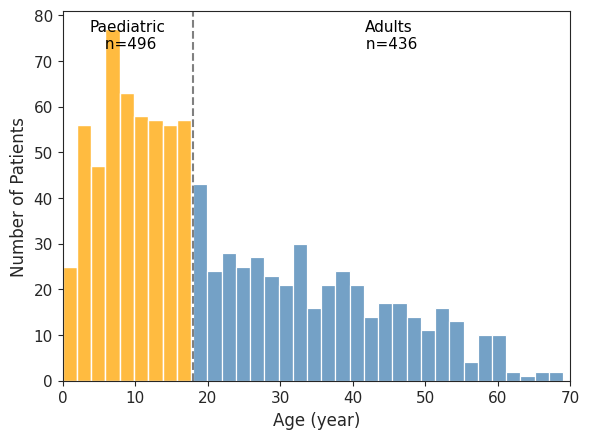

In [ ]:
# --- Load CSV ---
df = pd.read_csv("/path/to/patient_demographics.csv")

# --- Create combined age column ---
df["age"] = df["surgery_age"].fillna(df["preop_age"])

# --- Count missing both ---
missing_both = df["age"].isna().sum()
print(f"Number of patients without both surgery_age and preop_age: {missing_both}")

with sns.axes_style("ticks"):
        fig, ax = plt.subplots(figsize=(6,4.5))

        # --- Split ages ---
        ages = df["age"].dropna()
        ages_paed = ages[ages < 18]
        ages_adult = ages[ages >= 18]

        # --- Plot paediatric (orange) ---
        sns.histplot(ages_paed, bins=9, ax=ax, color="orange", edgecolor="white")

        # --- Plot adult (blue) ---
        sns.histplot(ages_adult, bins=26, ax=ax, color="steelblue", edgecolor="white")

        # --- Axes / labels ---
        ax.set_xlim(0,70)
        plt.axvline(x=18, linestyle="--", color="grey", linewidth=1.5, label="Paediatric cutoff (18)")

        plt.xlabel("Age (year)", fontsize=12)
        plt.ylabel("Number of Patients", fontsize=12)
        plt.title("")
        plt.xticks(fontsize=11)
        plt.yticks(fontsize=11)
        
        # --- Add text with total counts ---
        paed_count = len(ages_paed)
        adult_count = len(ages_adult) 

        # Find max y value from the histogram to position text nicely
        ymax = ax.get_ylim()[1]

        ax.text(9, ymax*0.90, f"Paediatric\n n={paed_count}", 
                ha="center", color="black", fontsize=11)

        ax.text(45, ymax*0.90, f"Adults\n n={adult_count}", 
                ha="center", color="black", fontsize=11)

        plt.tight_layout()
        plt.show()                                      
